SOW-BKI230A Deep Learning<br>Spring 2025

Assignment 4<br>Convolutional Neural Networks

## 1. Assignment Introduction

This assignment focuses on implementing the convolutional sketch inversion technique, based on the study titled "Convolutional Sketch Inversion" by Yağmur Güçlütürk, Umut Güçlü, Rob van Lier, and Marcel A. J. van Gerven, published in 2016. The core concept behind this technique is to transform sketches back into photo-realistic images by leveraging Convolutional Neural Networks (CNNs). This process is intriguing for multiple domains ranging from artistic image generation to aiding in forensic investigations due to its ability to reconstruct detailed images from mere sketches.

The convolutional sketch inversion method is designed to reverse the sketching process, thereby infilling missing textures, colors, and details that are not present in original sketches. Although the original research utilizes a specific dataset, for educational purposes, this assignment will employ an alternative dataset available in PyTorch. Additionally, a simplified method will be utilized for converting images into sketches before attempting the inversion.

The objectives of this assignment are as follows:
1. To gain an understanding of the convolutional sketch inversion method.
2. To prepare and preprocess the dataset by converting images into sketches.
3. To implement a CNN model capable of converting sketches back into images.
4. To analyze the results by comparing reconstructed images with their original counterparts.
5. To respond to homework questions designed to assess understanding and application of the method.

This assignment provides a practical opportunity to explore and implement deep learning techniques specifically related to image processing and convolutional neural networks. Through this exercise, learners will enhance their skills in handling image data, designing neural network architectures, and understanding the overall process of learning from visual abstractions to detailed reconstructions.

## 2. Method Background

The convolutional sketch inversion method leverages Convolutional Neural Networks (CNNs) to transform simple sketches into detailed, photo-realistic images. The underlying concept reverses the traditional sketching process, where detailed real-world images are abstracted into line drawings; sketch inversion, on the contrary, aims to infill the absent textures, colors, and other nuanced details to either recreate the original image or produce a close approximation of it.

In their study, Güçlütürk et al. extensively explored this concept using a dataset explicitly curated with images and their corresponding hand-drawn sketches. The model they developed through training was capable of discerning complex patterns and features essential for generating realistic images from mere line drawings. This method stands out due to its inverse approach to sketching, filling in the gaps of information typically lost in the simplification process inherent in drawing sketches.

The significance of this method spans across various domains:
- **Art and Design:** It offers artists and designers a tool to swiftly generate realistic scenes from basic sketches, enhancing the creative process.
- **Forensic Applications:** It aids in creating clearer images from sketch descriptions of suspects, potentially improving identification efforts.
- **Education:** It serves as a practical tool in teaching concepts of image processing, machine learning, and the interpretation of abstract visual data.

Our approach in this assignment adopts a slight variation from the original work, primarily due to dataset accessibility and to align it with educational goals. Instead of using the specific dataset employed in the original research, we will use a readily available dataset from PyTorch's torchvision datasets, like LFW. To simulate sketches, a basic edge detection algorithm will be applied to the images, creating a pseudo-sketch dataset. This approach, while simplified, encapsulates the essence of convolutional sketch inversion – instructing the network to deduce missing details based on the limited information provided by sketches.

In the subsequent sections, we will delve into the data preparation process, which involves the conversion of images to sketches for our dataset. Following that, we will outline the design and training of a convolutional neural network tailored for achieving sketch inversion.

In [ ]:
#!nvidia-smi

Wed Apr 23 11:34:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. Implementation Preliminaries

Before diving into the implementation of the convolutional sketch inversion technique, it is crucial to set up the coding environment properly to ensure smooth execution and experimentation. This section outlines the necessary steps for environment setup, including installing required libraries and verifying hardware capabilities.

### Environment Setup

1. **GPU Verification:** To expedite the training process, ensure that the coding environment has access to a Graphics Processing Unit (GPU). This can be verified by executing the command `!nvidia-smi`, which provides information about the GPU device if available.

2. **Library Installation:** The implementation requires PyTorch, a leading library for developing deep learning models. If PyTorch is not installed, it can be added to the environment using the package manager pip by running `!pip install torch torchvision torchaudio`. This command also installs torchvision and torchaudio, libraries that provide utilities for working with image and audio data, respectively.

### Library Import

After setting up the environment, import the necessary libraries to facilitate model development, data handling, and visualization:

```python
import torch
import torchvision
from torchvision import transforms
from torch import nn, optim
import matplotlib.pyplot as plt
import numpy as np
```

### Verification

Finally, verify the versions of PyTorch and the availability of CUDA, which is essential for GPU acceleration. This step ensures that all installations are successful and the environment is ready for implementation activities:

```python
print(torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
```

By following these steps, the environment will be suitably prepared for implementing the convolutional sketch inversion technique, from data preprocessing to model training and evaluation.

In [2]:
import torch
import torchvision
from torchvision import transforms
from torch import nn, optim
import matplotlib.pyplot as plt
import numpy as np

print(torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

2.6.0+cu124
CUDA Available: True


## 4. Dataset and Preprocessing

The creation of a pseudo-sketch dataset for training the convolutional sketch inversion model is a pivotal step in this assignment. Since the original approach used unique datasets, we adapt the method to employ the LFWPeople dataset. This section describes the procedure to load this dataset and preprocess the images to generate sketches simulating the input for sketch inversion.

### Loading the LFWPeople Dataset

The LFWPeople dataset comprises face images intended for studying unconstrained face recognition. It serves as an excellent basis for our purpose, simulating the sketch inversion process. The process begins with loading the dataset and applying initial transformations:

```python
from torchvision.datasets import ImageFolder
from torchvision.datasets.utils import download_and_extract_archive, check_integrity
from torchvision.transforms import Compose, ToTensor, Normalize, Grayscale, Resize
from torch.utils.data import DataLoader

# Download the data
dataset_root = './data'
download_and_extract_archive("https://figshare.com/ndownloader/files/5976015", dataset_root, filename='lfw-funneled.tgz', md5='1b42dfed7d15c9b2dd63d5e5840c86ad')

# Define transformations for dataset loading
transform = Compose([
    Resize((64, 64)),  # Ensure uniform size
    ToTensor(),        # Convert image to Tensor format
])

# Load the dataset
lfw_dataset = ImageFolder(root=dataset_root, transform=transform)

# Display dataset size
print(f'Size of the dataset: {len(lfw_dataset)} items.')
```

This portion of the dataset is initially transformed to a uniform size and converted to tensor format, preparing it for further manipulation.

### Creating Pseudo-Sketches Using Edge Detection

To approximate sketches, we utilize a simple edge detection algorithm. This method simplifies the images into essential outlines and details, emulating a hand-drawn sketch effect. The implementation of the edge detection filter is as follows:

```python
from torchvision.transforms.functional import rgb_to_grayscale, to_pil_image, to_tensor
from scipy.ndimage import convolve

def edge_detection(image_tensor):
    """
    Simple edge detection to create pseudo-sketch
    """
    # Convert image to grayscale
    image_tensor = rgb_to_grayscale(image_tensor)
    image_np = image_tensor.squeeze().numpy()
    
    # Define edge detection kernel
    kernel = np.array([[-1, -1, -1],
                       [-1,  8, -1],
                       [-1, -1, -1]])
    
    # Apply convolution for edge detection
    edges = convolve(image_np, kernel, mode='constant', cval=0.0)
    
    # Normalize the edge values
    edges = (edges - np.min(edges)) / (np.max(edges) - np.min(edges))
    
    # Convert back to Tensor format
    sketch_tensor = to_tensor(edges).float()
    return sketch_tensor.unsqueeze(0)  # Add channel dimension
```

With this method, images from the LFWPeople dataset can be processed into sketches, setting the stage for the next part of our assignment: training a neural network to reverse this transformation.

This preprocessing step is crucial for the creation of the dataset that will be used to train our sketch inversion model. By converting real images into their sketch equivalents, we allow our model to learn the translation from an abstract representation back to a detailed, photorealistic image.

In [3]:
from torchvision.datasets import ImageFolder
from torchvision.datasets.utils import download_and_extract_archive, check_integrity
from torchvision.transforms import Compose, ToTensor, Normalize, Grayscale, Resize
from torch.utils.data import DataLoader

# Download the data
dataset_root = './data'
download_and_extract_archive("https://figshare.com/ndownloader/files/5976015", dataset_root, filename='lfw-funneled.tgz', md5='1b42dfed7d15c9b2dd63d5e5840c86ad')

# Define transformations for dataset loading
transform = Compose([
    Resize((64, 64)),  # Ensure uniform size
    ToTensor(),        # Convert image to Tensor format
])

# Load the dataset
lfw_dataset = ImageFolder(root=dataset_root, transform=transform)

# Display dataset size
print(f'Size of the dataset: {len(lfw_dataset)} items.')

from torchvision.transforms.functional import rgb_to_grayscale, to_pil_image, to_tensor
from scipy.ndimage import convolve

def edge_detection(image_tensor):
    """
    Simple edge detection to create pseudo-sketch
    """
    # Convert image to grayscale
    image_tensor = rgb_to_grayscale(image_tensor)
    image_np = image_tensor.squeeze().numpy()

    # Define edge detection kernel
    kernel = np.array([[-1, -1, -1],
                       [-1,  8, -1],
                       [-1, -1, -1]])

    # Apply convolution for edge detection
    edges = convolve(image_np, kernel, mode='constant', cval=0.0)

    # Normalize the edge values
    edges = (edges - np.min(edges)) / (np.max(edges) - np.min(edges))

    # Convert back to Tensor format
    sketch_tensor = to_tensor(edges).float()
    return sketch_tensor.unsqueeze(0)  # Add channel dimension

100%|██████████| 243M/243M [00:29<00:00, 8.27MB/s]


Size of the dataset: 13233 items.


## 5. Model Architecture

For the convolutional sketch inversion task, the proposed model employs an encoder-decoder architecture. This architecture is effective for learning compressed representations (encodings) of the input data and then decoding these representations back into the original data format. The encoder progressively down-samples and compresses the input, while the decoder gradually up-samples and reconstructs the information.

### Encoder-Decoder Architecture

The model comprises two main components:

1. **Encoder:** Utilizes strided convolutional layers to down-sample and encode the input sketches into a compact latent representation. Each convolutional layer is followed by batch normalization and LeakyReLU activation, except for the first convolutional layer, which is directly followed by LeakyReLU.

2. **Decoder:** Employs transpose convolutional layers to up-sample the encoded latent representation back to the original image dimensions. Each transpose convolutional layer is followed by batch normalization and ReLU activation. The final layer uses a tanh activation function (without batch normalization) to produce the output image, ensuring the output pixel values are normalized between -1 and 1.

### Model Definition

The following code snippet defines the `SketchInversionCNN` class embodying this architecture:

```python
class SketchInversionCNN(nn.Module):
    def __init__(self):
        super(SketchInversionCNN, self).__init__()

        self.encoder = nn.Sequential(
            # Input: 1 x 64 x 64 (grayscale image)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),  # 64 x 32 x 32
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),  # 128 x 16 x 16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),  # 256 x 8 x 8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.decoder = nn.Sequential(
            # Input: 256 x 8 x 8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),  # 128 x 16 x 16
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),  # 64 x 32 x 32
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),  # 3 x 64 x 64 (RGB image)
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
```

By implementing this structure, we aim to train a model capable of accurately inverting sketches back into color images. The architecture is carefully designed to handle the specific demands of sketch inversion, balancing the need for sufficient model complexity with the constraints of training efficiency and resource usage.

In [4]:
class SketchInversionCNN(nn.Module):
    def __init__(self):
        super(SketchInversionCNN, self).__init__()

        self.encoder = nn.Sequential(
            # Input: 1 x 64 x 64 (grayscale image)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),  # 64 x 32 x 32
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),  # 128 x 16 x 16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),  # 256 x 8 x 8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.decoder = nn.Sequential(
            # Input: 256 x 8 x 8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),  # 128 x 16 x 16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),  # 64 x 32 x 32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),  # 3 x 64 x 64 (RGB image)
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

## 6. Model Training

After defining the model architecture, the next step is to detail the training procedure. Training a neural network involves iteratively optimizing its weights to minimize the difference between the predicted output and the actual target. For the sketch inversion task, the model learns to predict the original image from its sketch version.

### Loss Function and Optimizer

- **Loss Function:** The Mean Squared Error (MSE) loss is employed in this context, suitable for regression tasks like predicting pixel values. MSE measures the average squared difference between the estimated values and the actual value, providing a quantitative measure of model performance.
- **Optimizer:** The Adam optimizer is selected for its efficiency in managing variable learning rates for different parameters, improving convergence rates. It adjusts the model weights based on the computed gradients to minimize the loss.

### Training Loop

The training loop involves processing the input data in batches, performing forward and backward passes, and updating the model weights. Key steps include:

1. **Batch Processing:** Data is processed in minibatches to optimize memory usage and computational efficiency.
2. **Gradient Computation:** During the backward pass, gradients of the loss with respect to model parameters are computed.
3. **Weight Update:** The optimizer updates the model parameters based on the computed gradients.

### Training Code

The following code outlines the training process:

```python
# Initialize the model and set to device
model = SketchInversionCNN().to(device)

# Setup loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

# Training parameters
epochs = 25
batch_size = 64

# DataLoader for original images with normalization
transform_original = Compose([
    Resize((64, 64)),
    ToTensor(),
    Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

lfw_dataset_original = ImageFolder(root='./data', transform=transform_original)
dataloader_original = DataLoader(lfw_dataset_original, batch_size=batch_size, shuffle=True)

# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for i, data in enumerate(dataloader_original, 0):
        original_images, _ = data
        sketches = torch.cat([edge_detection(img) for img in original_images]).to(device)
        
        optimizer.zero_grad()
        outputs = model(sketches)
        loss = criterion(outputs, original_images.to(device))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'Epoch: {epoch + 1}, Batch: {i + 1}, Loss: {running_loss / 100:.4f}')
            running_loss = 0.0

print('Finished Training')
```

This training procedure iteratively optimizes the model to minimize the discrepancy between the reconstructed images and the original ones, advancing towards achieving the goal of sketch inversion. As the model trains, it learns to fill in the textures, colors, and details absent in the sketch inputs, demonstrating the power of convolutional neural networks in understanding and reproducing complex image data.

In [5]:
# Initialize the model and set to device
model = SketchInversionCNN().to(device)

# Setup loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

# Training parameters
epochs = 25
batch_size = 64

# DataLoader for original images with normalization
transform_original = Compose([
    Resize((64, 64)),
    ToTensor(),
    Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

lfw_dataset_original = ImageFolder(root='./data', transform=transform_original)
dataloader_original = DataLoader(lfw_dataset_original, batch_size=batch_size, shuffle=True)

# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for i, data in enumerate(dataloader_original, 0):
        original_images, _ = data
        sketches = torch.cat([edge_detection(img) for img in original_images]).to(device)
        optimizer.zero_grad()
        outputs = model(sketches)
        loss = criterion(outputs, original_images.to(device))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'Epoch: {epoch + 1}, Batch: {i + 1}, Loss: {running_loss / 100:.4f}')
            running_loss = 0.0

print('Finished Training')

Epoch: 1, Batch: 100, Loss: 0.2802
Epoch: 1, Batch: 200, Loss: 0.1182
Epoch: 2, Batch: 100, Loss: 0.0743
Epoch: 2, Batch: 200, Loss: 0.0633
Epoch: 3, Batch: 100, Loss: 0.0576
Epoch: 3, Batch: 200, Loss: 0.0538
Epoch: 4, Batch: 100, Loss: 0.0513
Epoch: 4, Batch: 200, Loss: 0.0483
Epoch: 5, Batch: 100, Loss: 0.0470
Epoch: 5, Batch: 200, Loss: 0.0464
Epoch: 6, Batch: 100, Loss: 0.0450
Epoch: 6, Batch: 200, Loss: 0.0444
Epoch: 7, Batch: 100, Loss: 0.0435
Epoch: 7, Batch: 200, Loss: 0.0432
Epoch: 8, Batch: 100, Loss: 0.0415
Epoch: 8, Batch: 200, Loss: 0.0410
Epoch: 9, Batch: 100, Loss: 0.0406
Epoch: 9, Batch: 200, Loss: 0.0403
Epoch: 10, Batch: 100, Loss: 0.0397
Epoch: 10, Batch: 200, Loss: 0.0397
Epoch: 11, Batch: 100, Loss: 0.0382
Epoch: 11, Batch: 200, Loss: 0.0381
Epoch: 12, Batch: 100, Loss: 0.0374
Epoch: 12, Batch: 200, Loss: 0.0379
Epoch: 13, Batch: 100, Loss: 0.0365
Epoch: 13, Batch: 200, Loss: 0.0369
Epoch: 14, Batch: 100, Loss: 0.0363
Epoch: 14, Batch: 200, Loss: 0.0364
Epoch: 15,

## 7. Model Evaluation and Visualization

Evaluating the performance of the convolutional sketch inversion model involves both qualitative and quantitative assessments. Qualitative evaluation can be visually performed by comparing original images, their sketch versions, and the reconstructed images. Meanwhile, quantitative evaluation focuses on computing metrics like Mean Squared Error (MSE) on the test set to objectively measure the model's reconstruction accuracy.

### Visual Evaluation

To visually assess the model's performance, we create a function that takes a batch of images from the test set, generates sketches from these images, feeds the sketches through the model to obtain reconstructions, and displays the originals, sketches, and reconstructions side by side for comparison.

```python
def visualize_reconstructions(model, data_loader, device, num_images=5):
    model.eval()
    with torch.no_grad():
        data = next(iter(data_loader))
        original_images, _ = data
        sketches = torch.cat([edge_detection(img) for img in original_images]).to(device)
        outputs = model(sketches)
        
        fig, axs = plt.subplots(3, num_images, figsize=(10, 6))

        for i in range(num_images):
            axs[0, i].imshow(to_pil_image(original_images[i]).convert("RGB"))
            axs[0, i].set_title('Original')
            axs[1, i].imshow(to_pil_image(sketches[i].cpu().squeeze()), cmap='gray')
            axs[1, i].set_title('Sketch')
            axs[2, i].imshow(to_pil_image(0.5 * outputs[i].cpu() + 0.5).convert("RGB"))
            axs[2, i].set_title('Reconstructed')

            for ax in axs[:, i]:
                ax.axis('off')

        plt.tight_layout()
        plt.show()

# Sample visualization on the test dataset
data_loader_test = DataLoader(lfw_dataset, batch_size=6, shuffle=True)
visualize_reconstructions(model, data_loader_test, device, num_images=5)
```

### Quantitative Evaluation

Quantitative evaluation on the test set involves computing the Mean Squared Error (MSE) between the reconstructed images and the original images, providing an objective measure of reconstruction accuracy.

```python
def compute_mse(model, data_loader, device):
    model.eval()
    total_mse = 0.0
    count = 0
    
    with torch.no_grad():
        for data in data_loader:
            original_images, _ = data
            sketches = torch.cat([edge_detection(img) for img in original_images]).to(device)
            outputs = model(sketches)
            mse = criterion(outputs, original_images.to(device)).item()
            total_mse += mse
            count += 1
    
    average_mse = total_mse / count
    return average_mse

# Computing the MSE on the test set
average_mse = compute_mse(model, data_loader_test, device)
print(f'Average MSE on the Test Set: {average_mse:.4f}')
```

This MSE value gives us an insight into how closely the model's reconstructions match the original images in a pixel-wise manner. A lower MSE indicates better reconstruction quality, while higher values suggest discrepancies between the reconstructions and the originals.

Through these evaluations, we can effectively gauge the model's performance in inverting sketches to photo-realistic images, highlighting both its strengths and areas for improvement.

### Conclusion

The process of model evaluation and visualization is essential for understanding the effectiveness of the applied convolutional sketch inversion technique. While visual inspections provide subjective insights into the reconstruction quality, quantitative metrics like MSE offer objective evaluations to guide further model refinement and development.

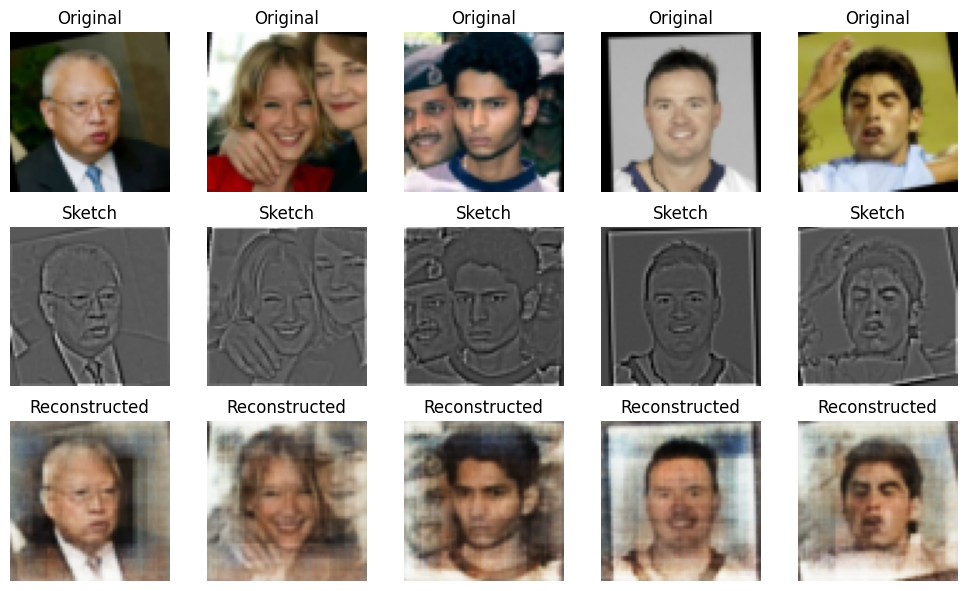

Average MSE on the Test Set: 0.2688


In [6]:
def visualize_reconstructions(model, data_loader, device, num_images=5):
    model.eval()
    with torch.no_grad():
        data = next(iter(data_loader))
        original_images, _ = data
        sketches = torch.cat([edge_detection(img) for img in original_images]).to(device)
        outputs = model(sketches)

        fig, axs = plt.subplots(3, num_images, figsize=(10, 6))

        for i in range(num_images):
            axs[0, i].imshow(to_pil_image(original_images[i]).convert("RGB"))
            axs[0, i].set_title('Original')
            axs[1, i].imshow(to_pil_image(sketches[i].cpu().squeeze()), cmap='gray')
            axs[1, i].set_title('Sketch')
            axs[2, i].imshow(to_pil_image(0.5 * outputs[i].cpu() + 0.5).convert("RGB"))
            axs[2, i].set_title('Reconstructed')

            for ax in axs[:, i]:
                ax.axis('off')

        plt.tight_layout()
        plt.show()

# Sample visualization on the test dataset
data_loader_test = DataLoader(lfw_dataset, batch_size=6, shuffle=True)
visualize_reconstructions(model, data_loader_test, device, num_images=5)

def compute_mse(model, data_loader, device):
    model.eval()
    total_mse = 0.0
    count = 0

    with torch.no_grad():
        for data in data_loader:
            original_images, _ = data
            sketches = torch.cat([edge_detection(img) for img in original_images]).to(device)
            outputs = model(sketches)
            mse = criterion(outputs, original_images.to(device)).item()
            total_mse += mse
            count += 1

    average_mse = total_mse / count
    return average_mse

# Computing the MSE on the test set
average_mse = compute_mse(model, data_loader_test, device)
print(f'Average MSE on the Test Set: {average_mse:.4f}')

## 8. Homework Questions

### Implementation Questions (Require Short Code)
**Note:** You can either implement them by editing the text below or implement them in the code above.

1. **Using Resize and Conv2D Layers Instead of ConvTranspose2d Layers:**
   Modify the decoder part of the `SketchInversionCNN` model to use `Resize` and `Conv2d` layers instead of `ConvTranspose2d` layers for up-sampling. Assume the resize operation upsamples the image to double its size.

   ```python
  class SketchInversionCNN_ResizeConv(nn.Module):
    def __init__(self):
        super(SketchInversionCNN_ResizeConv, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True)
        
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.Conv2d(64, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh())
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

   ```

2. **Experimenting with Different Model Architectures:**
   Write a PyTorch code snippet to add one more convolutional layer to both the encoder and decoder of the `SketchInversionCNN` model, including appropriate batch normalization and activation layers. Assume the new convolutional layer in the encoder compresses the representation further to a `512 x 4 x 4` layer, and the corresponding decoder layer decompresses it back.

   ```python
class SketchInversionCNN_Extended(nn.Module):
    def __init__(self):
        super(SketchInversionCNN_Extended, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True))
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),

            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh())
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

   ```

3. **Using a Different Evaluation Metric than MSE:**
   Implement code to calculate the Peak Signal-to-Noise Ratio (PSNR) between the reconstructed images and the original images as an additional evaluation metric. Assume `outputs` contains the reconstructed images, and `original_images` contains the ground truth.

   ```python
  def compute_psnr(outputs, original_images, max_pixel=1.0):
    mse = torch.mean((outputs - original_images) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * torch.log10(max_pixel / torch.sqrt(mse))
   ```

4. **Adding Dropout to the Model:**
   Modify the `SketchInversionCNN` model to include dropout layers in the encoder with a dropout rate of 0.5 after each LeakyReLU activation.

   ```python
  class SketchInversionCNN_Dropout(nn.Module):
    def __init__(self):
        super(SketchInversionCNN_Dropout, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Dropout(0.5),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Dropout(0.5),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Dropout(0.5))
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh())
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
   ```

5. **Modifying the Normalization Technique:**
   Replace the `BatchNorm2d` layers in the decoder of the `SketchInversionCNN` model with `InstanceNorm2d` layers. Write the code necessary for this modification.

   ```python
  class SketchInversionCNN_InstanceNorm(nn.Module):
    def __init__(self):
        super(SketchInversionCNN_InstanceNorm, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True))
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            
            nn.InstanceNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            
            nn.InstanceNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh())
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
   ```

### Reasoning Questions (Require Short Answers)

6. **Why might using `Resize` and `Conv2d` layers instead of `ConvTranspose2d` for up-sampling lead to different results in generated images?**
   
   Answer:

7. **What could be the potential impact of adding more convolutional layers to the model?**

   Answer:

8. **Why might calculating PSNR be useful in addition to MSE when evaluating reconstruction quality?**

   Answer:

9. **How does adding dropout to the model affect its training and final performance?**

   Answer:

10. **What is the advantage of using `InstanceNorm2d` over `BatchNorm2d` in certain situations?**

   Answer:

1-5) code after questions  
6)Resize + Conv2d gives a smoother image zoom without the 'checkboard arteffect 'that sometimes occurs in ConvTranspose2d. However, they may lose small details, as they are not trained for optimal magnification, unlike ConvTranspose2d.   
7)More layers → the model can learn more complex features, improving the quality of reconstruction. But it also increases the risk of overfitting, requires more data, and increases computational costs. That is why that is not a best option all the time (as well as less layers).  
8)PSNR is more convenient for comparison, as it takes into account the maximum possible pixel value. This makes the metric more versatile for different studies.
PSNR better reflects a person's perception of image quality, especially with small visual differences.  
9)Dropout "turns off" some of the neurons during training, which helps to avoid overfitting and improves the generalizing ability of the model. But learning can slow down due to increased stochasticity.  
10)InstanceNorm2d normalizes each image in a batch separately, which is useful for small batch sizes or for tasks where independent normalization (image styling) is important, for gerenaration tasks(because it normalizes over a single image, not the entire batch.). It is more stable when working with small batches.  

## 9. Assignment Conclusion

This assignment provided a comprehensive exploration of the convolutional sketch inversion technique, leveraging the capabilities of Convolutional Neural Networks (CNNs) to transform simple sketches back into detailed, photo-realistic images. Key components of the assignment involved setting up the coding environment, understanding the theoretical background of the method, handling and preprocessing a dataset for sketch conversion, architecting and training a CNN model, and evaluating the model both qualitatively and quantitatively.

Through the implementation tasks, you've gained hands-on experience with various aspects of neural network design and optimization, including modifying model architectures, adding regularization techniques like dropout, and experimenting with different normalization layers. The reasoning questions offered insights into the choices and impacts of different model components and evaluation metrics, emphasizing the importance of both pixel-wise accuracy and perceptual quality in image reconstruction tasks.

By concluding this assignment, it is hoped that you've not only solidified your understanding of convolutional neural networks and their application in image processing tasks but also appreciated the intricacies involved in transforming abstract visual data into detailed reconstructions. This exercise underscores the potential of deep learning in bridging the gap between simplicity and complexity, abstraction and realism, paving the way for innovations in art, design, forensics, and beyond.

The skills and knowledge acquired through this assignment lay a foundation for further exploration into the vast and evolving field of deep learning, encouraging continuous learning and experimentation.